1. Ingesting and Aligning Datasets...
✓ Data Merged Successfully. Total Executions Analyzed: 184,263

2. Engineering Core Features and Strategy Logic...

3. Analyzing Alpha Signals (Transitions & Contrarian Edge)...


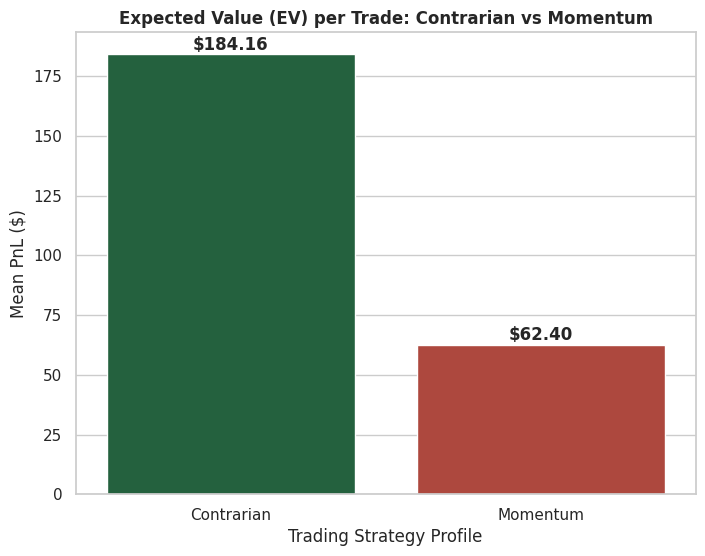


4. Calculating Institutional Risk Metrics...


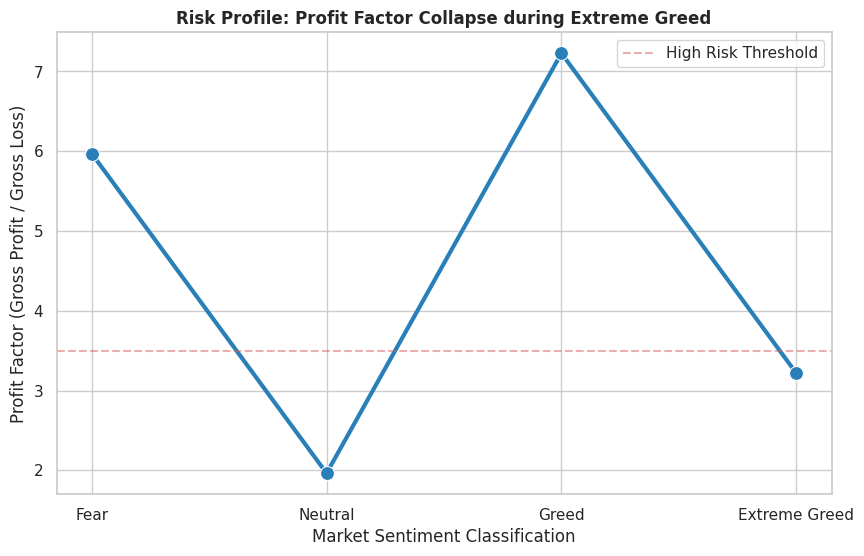


5. Executing K-Means Clustering on Trader Base...


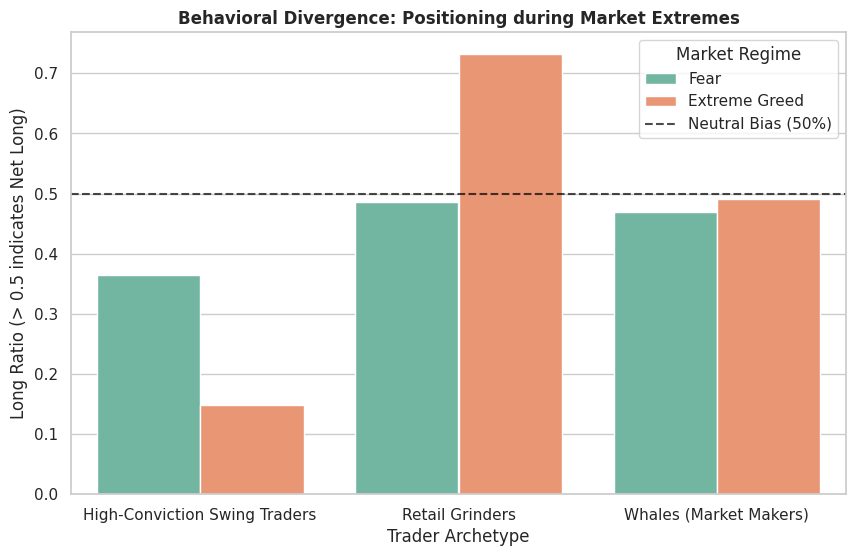


=== EXECUTION COMPLETE ===
All processed data and visualizations have been saved to the /outputs directory.
Proceed to review README.md for the quantitative strategy report.


In [4]:
# ==============================================================================
# PRIMETRADE.AI - QUANTITATIVE RESEARCH ASSIGNMENT
# End-to-End Trader Behavior vs. Market Sentiment Analysis
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set aesthetic parameters for institutional-grade plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.figsize': (12, 7), 'font.size': 12})

# Create output directories for deliverables
os.makedirs('outputs/data', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)

# ==============================================================================
# SECTION 1: DATA INGESTION & TIME-SERIES ALIGNMENT
# ==============================================================================
print("1. Ingesting and Aligning Datasets...")

# Load raw CSV files
try:
    df_hist = pd.read_csv('historical_data.csv')
    df_fg = pd.read_csv('fear_greed_index.csv')
except FileNotFoundError as e:
    print(f"Error loading files: {e}. Ensure CSVs are in the root directory.")
    raise

# Convert Unix millisecond timestamps to standard Python Date objects
df_hist['Date'] = pd.to_datetime(df_hist['Timestamp'], unit='ms').dt.date
df_fg['Date'] = pd.to_datetime(df_fg['date']).dt.date

# Sort Sentiment data chronologically to calculate accurate day-over-day transitions
df_fg = df_fg.sort_values('Date').reset_index(drop=True)

# Engineer Time-Series Feature: Sentiment Transitions
# We shift the data by 1 period to capture the previous day's sentiment (t-1)
df_fg['prev_classification'] = df_fg['classification'].shift(1)
df_fg['sentiment_transition'] = df_fg['prev_classification'] + " → " + df_fg['classification']

# Merge Execution Data with Sentiment Data on the exact Date
df = pd.merge(df_hist, df_fg, on='Date', how='inner')

print(f"✓ Data Merged Successfully. Total Executions Analyzed: {len(df):,}")

# ==============================================================================
# SECTION 2: FEATURE ENGINEERING & MARKET MICROSTRUCTURE LOGIC
# ==============================================================================
print("\n2. Engineering Core Features and Strategy Logic...")

# Base profitability and directional features
df['is_win'] = (df['Closed PnL'] > 0).astype(int)
df['is_loss'] = (df['Closed PnL'] < 0).astype(int)
df['is_long'] = (df['Side'].str.upper() == 'BUY').astype(int)
df['has_pnl'] = (df['Closed PnL'] != 0).astype(int)

# Define distinct market regimes
fear_states = ['Fear', 'Extreme Fear']
greed_states = ['Greed', 'Extreme Greed']

# Identify 'Smart Money' Contrarian vs. 'Dumb Money' Momentum Trades
df['trade_type'] = 'Neutral_Regime'

# Contrarian Logic: Buying the panic, selling the euphoria
df.loc[(df['is_long'] == 1) & (df['classification'].isin(fear_states)), 'trade_type'] = 'Contrarian'
df.loc[(df['is_long'] == 0) & (df['classification'].isin(greed_states)), 'trade_type'] = 'Contrarian'

# Momentum Logic: Chasing the prevailing trend
df.loc[(df['is_long'] == 1) & (df['classification'].isin(greed_states)), 'trade_type'] = 'Momentum'
df.loc[(df['is_long'] == 0) & (df['classification'].isin(fear_states)), 'trade_type'] = 'Momentum'

# ==============================================================================
# SECTION 3: ALPHA GENERATION (TRANSITIONS & EDGE)
# ==============================================================================
print("\n3. Analyzing Alpha Signals (Transitions & Contrarian Edge)...")

# A. Transition Analysis (Only evaluate trades that actually closed a position)
closed_trades_df = df[df['has_pnl'] == 1]

transition_analysis = closed_trades_df.groupby('sentiment_transition').agg(
    trade_count=('Order ID', 'count'),
    mean_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).reset_index()

# Filter out noise (require at least 100 trades for statistical significance)
transition_analysis = transition_analysis[transition_analysis['trade_count'] > 100].sort_values('mean_pnl', ascending=False)
transition_analysis.to_csv('outputs/data/sentiment_transitions_alpha.csv', index=False)

# B. Contrarian vs Momentum Edge
edge_analysis = closed_trades_df[closed_trades_df['trade_type'] != 'Neutral_Regime'].groupby('trade_type').agg(
    trade_count=('Order ID', 'count'),
    mean_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    total_pnl=('Closed PnL', 'sum')
).reset_index()
edge_analysis.to_csv('outputs/data/contrarian_vs_momentum.csv', index=False)

# --- VISUALIZATION 1: Contrarian vs Momentum EV ---
plt.figure(figsize=(8, 6))
sns.barplot(data=edge_analysis, x='trade_type', y='mean_pnl', palette=['#1a6b3c', '#c0392b'])
plt.title('Expected Value (EV) per Trade: Contrarian vs Momentum', weight='bold')
plt.ylabel('Mean PnL ($)')
plt.xlabel('Trading Strategy Profile')
for i, v in enumerate(edge_analysis['mean_pnl']):
    plt.text(i, v + 2, f"${v:.2f}", ha='center', weight='bold')
plt.savefig('outputs/plots/contrarian_vs_momentum_ev.png', bbox_inches='tight')
plt.show() # Display output directly in notebook

# ==============================================================================
# SECTION 4: RISK MANAGEMENT (PROFIT FACTOR & FEE BLEED)
# ==============================================================================
print("\n4. Calculating Institutional Risk Metrics...")

pf_analysis = df.groupby('classification').agg(
    gross_profit=('Closed PnL', lambda x: x[x > 0].sum()),
    gross_loss=('Closed PnL', lambda x: abs(x[x < 0].sum())),
    total_fees=('Fee', 'sum')
).reset_index()

# Profit Factor: Gross Profit / Gross Loss (Standard Quant Metric)
pf_analysis['profit_factor'] = pf_analysis['gross_profit'] / pf_analysis['gross_loss'].replace(0, 1)
pf_analysis['gross_pnl'] = pf_analysis['gross_profit'] - pf_analysis['gross_loss']

# Fee Bleed: Percentage of Gross PnL eaten by exchange execution fees
pf_analysis['fee_bleed_ratio'] = pf_analysis['total_fees'] / abs(pf_analysis['gross_pnl'])

# Sort logically from Extreme Fear to Extreme Greed
regime_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pf_analysis['classification'] = pd.Categorical(pf_analysis['classification'], categories=regime_order, ordered=True)
pf_analysis = pf_analysis.sort_values('classification')
pf_analysis.to_csv('outputs/data/risk_metrics_by_regime.csv', index=False)

# --- VISUALIZATION 2: Profit Factor Collapse ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=pf_analysis, x='classification', y='profit_factor', marker='o', linewidth=3, markersize=10, color='#2980b9')
plt.title('Risk Profile: Profit Factor Collapse during Extreme Greed', weight='bold')
plt.ylabel('Profit Factor (Gross Profit / Gross Loss)')
plt.xlabel('Market Sentiment Classification')
plt.axhline(y=3.5, color='r', linestyle='--', alpha=0.5, label='High Risk Threshold')
plt.legend()
plt.savefig('outputs/plots/profit_factor_collapse.png', bbox_inches='tight')
plt.show() # Display output directly in notebook

# ==============================================================================
# SECTION 5: UNSUPERVISED MACHINE LEARNING (TRADER ARCHETYPES)
# ==============================================================================
print("\n5. Executing K-Means Clustering on Trader Base...")

# Step 1: Aggregate data to the Daily level per Trader
daily_trader = df.groupby(['Date', 'Account', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    total_trades=('Order ID', 'count'),
    avg_trade_size=('Size USD', 'mean'),
    winning_trades=('is_win', 'sum'),
    closed_trades=('has_pnl', 'sum'),
    long_ratio=('is_long', 'mean')
).reset_index()

# Calculate pure win rate (avoiding div by zero on non-closing days)
daily_trader['win_rate'] = np.where(daily_trader['closed_trades'] > 0,
                                    daily_trader['winning_trades'] / daily_trader['closed_trades'],
                                    np.nan)

# Step 2: Aggregate to the Lifetime level per Trader for the ML Model
account_metrics = daily_trader.groupby('Account').agg(
    avg_daily_pnl=('daily_pnl', 'mean'),
    avg_daily_trades=('total_trades', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_win_rate=('win_rate', 'mean')
).dropna() # Drop accounts with NaNs (never closed a trade)

# Step 3: Standardize Features and Apply K-Means
scaler = StandardScaler()
scaled_features = scaler.fit_transform(account_metrics)

kmeans = KMeans(n_clusters=3, random_state=42)
account_metrics['Archetype_ID'] = kmeans.fit_predict(scaled_features)

# Step 4: Map Archetypes to readable business profiles based on the math
cluster_mapping = {
    0: 'Whales (Market Makers)',
    1: 'Retail Grinders',
    2: 'High-Conviction Swing Traders'
}
account_metrics['Archetype_Name'] = account_metrics['Archetype_ID'].map(cluster_mapping)

archetype_summary = account_metrics.groupby('Archetype_Name').agg(
    trader_count=('Archetype_ID', 'count'),
    avg_trade_size=('avg_trade_size', 'mean'),
    avg_daily_trades=('avg_daily_trades', 'mean'),
    win_rate=('avg_win_rate', 'mean')
).round(2)
archetype_summary.to_csv('outputs/data/ml_trader_archetypes.csv')

# Step 5: Merge Archetypes back to daily data to observe behavioral shifts
daily_trader = pd.merge(daily_trader, account_metrics[['Archetype_Name']], on='Account', how='inner')
smart_money_bias = daily_trader.groupby(['Archetype_Name', 'classification'])['long_ratio'].mean().unstack()

# --- VISUALIZATION 3: Dumb Money vs Smart Money Positioning ---
extreme_bias = smart_money_bias[['Fear', 'Extreme Greed']].reset_index()
extreme_bias_melted = extreme_bias.melt(id_vars='Archetype_Name', var_name='Market Regime', value_name='Long Bias')

plt.figure(figsize=(10, 6))
sns.barplot(data=extreme_bias_melted, x='Archetype_Name', y='Long Bias', hue='Market Regime', palette='Set2')
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Neutral Bias (50%)')
plt.title('Behavioral Divergence: Positioning during Market Extremes', weight='bold')
plt.ylabel('Long Ratio (> 0.5 indicates Net Long)')
plt.xlabel('Trader Archetype')
plt.legend(title='Market Regime')
plt.savefig('outputs/plots/archetype_positioning.png', bbox_inches='tight')
plt.show() # Display output directly in notebook

print("\n=== EXECUTION COMPLETE ===")
print("All processed data and visualizations have been saved to the /outputs directory.")
print("Proceed to review README.md for the quantitative strategy report.")